In [51]:
import matplotlib.pyplot as plt
import robotic as ry
import numpy as np
import time
import os
import re
import open3d as o3d

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [2]:
ry.clear_params()

ry.params_add({'Render/renderShadow': False})

# This is Dog Shit code, do not read it, you may get a brain damage!

In [3]:
# loading, randomly placing and coloring the voxels. 
base = "../voxel_generation/data/"
C = ry.Config()
ids = []
p = [0, 0, .05]
for i, file in enumerate(os.listdir(base)[:5]):
    ids.append(file.split('.')[0])
    C.addFile(base+file, namePrefix = file.split('.')[0] + "_").setPosition(p)

    if np.random.rand() > .6:
        p[0] += .2
    elif np.random.rand() > .3:
        p[1] += .2
    else:
        p[2] += .2

for id in ids:
    pattern = re.compile(rf"{id}_" + "cube*")
    filtered = [x for x in C.getFrameNames() if pattern.search(x)]

    c = np.random.rand(3)
    for cube in filtered:
        C.getFrame(cube).setColor(c)

In [4]:
# calculating the maximum volume of the joing bounding box of all the voxels. This would help to align the camera
min_corner = np.array([np.inf, np.inf, np.inf])
max_corner = np.array([-np.inf, -np.inf, -np.inf])

for f in C.getFrames():
    size = f.getSize()
    if size is None or len(size) < 3:
        continue

    pos = np.array(f.getPosition())

    half = np.array(size[:3]) / 2

    min_corner = np.minimum(min_corner, pos - half)
    max_corner = np.maximum(max_corner, pos + half)

box_center = (max_corner + min_corner) / 2

In [37]:
# getting the image
def get_img(C:ry.Config, camera_view:ry.CameraView=None, cam_f:str="cam0"):
    if camera_view is None:
        camera_view = ry.CameraView(C)
    cam = C.getFrame(cam_f)
    camera_view.setCamera(cam)
    img, depth = camera_view.computeImageAndDepth(C)
    img = np.asarray(img)
    return img, depth, camera_view

In [8]:
C.view()

0

In [39]:
# aligning the camera to the center of the bounding box
C.addFrame("world").setPosition(box_center)

-- WARNING:kin.cpp:getFrame:481(-1) cannot find frame named 'cam_dim_0'
-- WARNING:kin.cpp:getFrame:481(-1) cannot find frame named 'cam_dim_1'
-- WARNING:kin.cpp:getFrame:481(-1) cannot find frame named 'cam_dim_2'
-- WARNING:kin.cpp:getFrame:481(-1) cannot find frame named 'cam_dim_3'
-- WARNING:kin.cpp:getFrame:481(-1) cannot find frame named 'cam_dim_4'


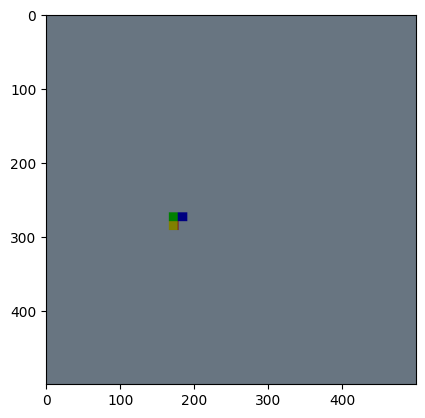

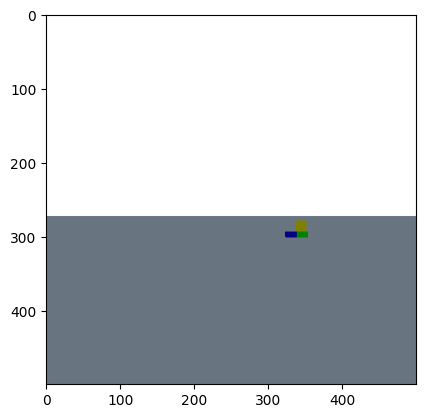

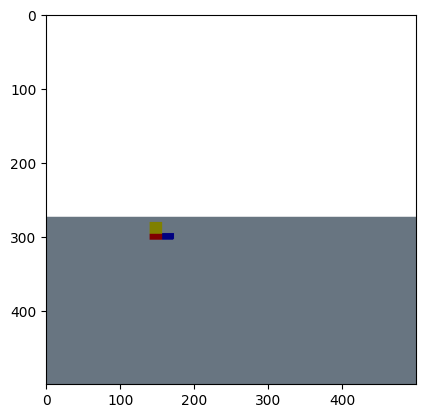

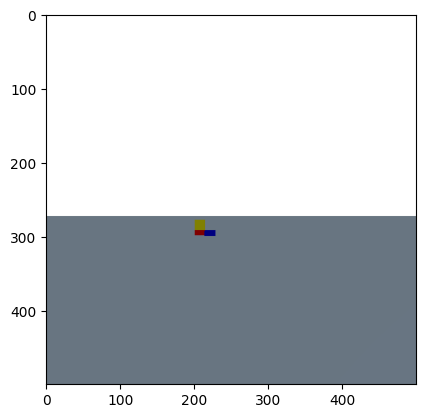

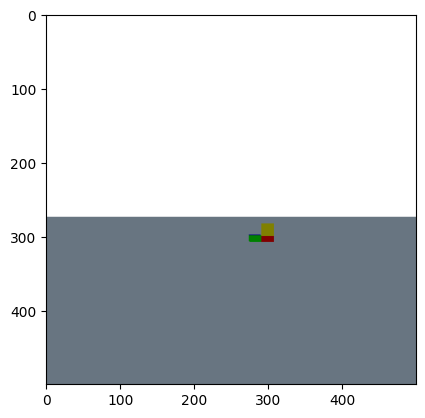

In [40]:
# getting images from different views
C.delFrame("cam_dim_0")
C.delFrame("cam_dim_1")
C.delFrame("cam_dim_2")
C.delFrame("cam_dim_3")
C.delFrame("cam_dim_4")

cam = C.addFrame(name="cam_dim_0", parent="world", args='Q:"t(0 0 5) d(180 1 0 0)", shape:camera, width:500, height:500')
cam = C.addFrame(name="cam_dim_1", parent="world", args='Q:"t(0 4 .1) d(180 1 0 0) d(-90 1 0 0) d(180 0 0 1)", shape:camera, width:500, height:500')
cam = C.addFrame(name="cam_dim_2", parent="world", args='Q:"t(0 -4 .1) d(180 1 0 0) d(90 1 0 0)", shape:camera, width:500, height:500')
cam = C.addFrame(name="cam_dim_3", parent="world", args='Q:"t(4 0 .1) d(180 1 0 0) d(-90 1 0 0) d(180 0 0 1) d(90 0 1 0)", shape:camera, width:500, height:500')
cam = C.addFrame(name="cam_dim_4", parent="world", args='Q:"t(-4 0 .1) d(180 1 0 0) d(-90 1 0 0) d(180 0 0 1) d(-90 0 1 0)", shape:camera, width:500, height:500')

depth_list = []
image_list = []
seg_list = []

for i in range(5):
    t = get_img(C=C, cam_f = f"cam_dim_{i}")
    # image_list.append(t[0])
    # depth_list.append(t[1])
    plt.imshow(t[2].computeSegmentationID())
    plt.show()
    
# np.save(f"./image_{0}.npy", np.array(image_list))
# np.save(f"./depth_{0}.npy", np.array(depth_list))
# np.save(f"./segmentation_{0}.npy", np.array(seg_list))

In [17]:
C.getJointIDs()

array([], dtype=uint32)

In [43]:
C = ry.Config()
C.addFile("../voxel_generation/data/7.g")
C.view()


0

In [31]:
C.view()

37

-- WARNING:kin.cpp:addFrame:145(-1) frame 'cam_dim_0' already exists! returning existing without modifications!
[1207.10681152 1207.10681152  250.          250.        ]


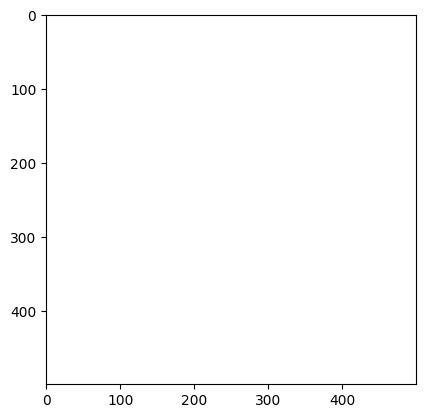

In [30]:
cam = C.addFrame(name="cam_dim_0", parent="world", args='Q:"t(0 0 5) d(180 1 0 0)", shape:camera, width:500, height:500')
t = get_img(C=C, cam_f = f"cam_dim_0")
plt.imshow(t[2].computeSegmentationImage())


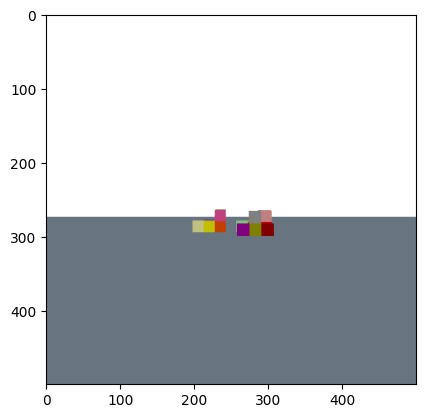

In [16]:
plt.imshow(t[2].computeSegmentationImage())

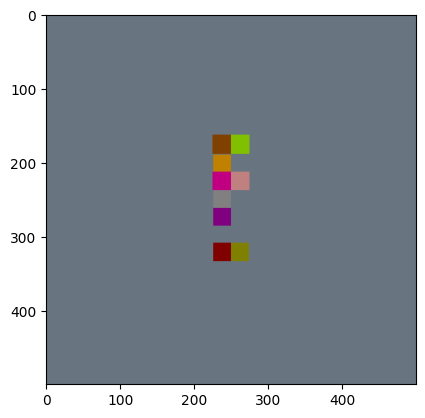

In [80]:
plt.imshow(t[2].computeSegmentationID())

In [81]:
t[2].computeSegmentationID()

array([[[104, 117, 129],
        [104, 117, 129],
        [104, 117, 129],
        ...,
        [104, 117, 129],
        [104, 117, 129],
        [104, 117, 129]],

       [[104, 117, 129],
        [104, 117, 129],
        [104, 117, 129],
        ...,
        [104, 117, 129],
        [104, 117, 129],
        [104, 117, 129]],

       [[104, 117, 129],
        [104, 117, 129],
        [104, 117, 129],
        ...,
        [104, 117, 129],
        [104, 117, 129],
        [104, 117, 129]],

       ...,

       [[104, 117, 129],
        [104, 117, 129],
        [104, 117, 129],
        ...,
        [104, 117, 129],
        [104, 117, 129],
        [104, 117, 129]],

       [[104, 117, 129],
        [104, 117, 129],
        [104, 117, 129],
        ...,
        [104, 117, 129],
        [104, 117, 129],
        [104, 117, 129]],

       [[104, 117, 129],
        [104, 117, 129],
        [104, 117, 129],
        ...,
        [104, 117, 129],
        [104, 117, 129],
        [104, 117, 129]]

In [10]:
# helps saving the environment
open("./highly_cluttered_env.g", "x").write(C.write())

1980

# Working on image generation

In [35]:
import sys
import os
from PandaTableVoxelClutterGenerator import PandaTableVoxelClutterGenerator
import robotic as ry

In [72]:
def get_img(C:ry.Config, camera_view:ry.CameraView=None, cam_f:str="cam0"):
    if camera_view is None:
        camera_view = ry.CameraView(C)
    cam = C.getFrame(cam_f)
    camera_view.setCamera(cam)
    img, depth = camera_view.computeImageAndDepth(C)
    img = np.asarray(img)
    return img, depth, camera_view

In [73]:
def calculate_center_of_pile(C):
    min_corner = np.array([np.inf, np.inf, np.inf])
    max_corner = np.array([-np.inf, -np.inf, -np.inf])
    
    for f in C.getFrames():
        size = f.getSize()
        if size is None or len(size) < 3:
            continue
    
        pos = np.array(f.getPosition())
    
        half = np.array(size[:3]) / 2
    
        min_corner = np.minimum(min_corner, pos - half)
        max_corner = np.maximum(max_corner, pos + half)
    
    return (max_corner + min_corner) / 2

In [82]:
def remove_panda(C):
    for frame in C.getFrameNames():
        if "l_" in frame or "target" in frame or frame in ['cameraTop', 'cameraWrist', 'panda_collCameraWrist']:
            C.delFrame(frame)

In [151]:
def main(idx):
    # ------------------------------------------------------------
    # Create the generator
    # ------------------------------------------------------------
    generator = PandaTableVoxelClutterGenerator(
        base_scene_file=ry.raiPath("../rai-robotModels/scenarios/pandaSingle.g"),
        voxel_dir="../../voxel_generation/data/",   # folder containing voxel .g files
        output_dir="./generated_envs",
        table_frame_name="table",
        gap=0.04,
        spawn_height=0.55,
        seed=14,
        per_cube_mass=0.2,
        table_shape_size=(1.6, 1.6, 0.08, 0.02),
        panda_base_relative_pos=(0.0, 0.0, 0.05),
        marker_thickness=0.004,
        spawn_half_mode="back",   # None, "left", "right", "front", "back"
    )

    # ------------------------------------------------------------
    # Generate one environment
    # ------------------------------------------------------------
    C, summary = generator.create_environment_with_refill(
        num_voxels=int(np.random.normal(10, 4)),
        sim_seconds=10.0,
        sim_dt=0.01,
        max_refill_rounds=10,
        xy_margin=0.02,
        z_tolerance=0.15,
        batch_spawn_count=5,
        add_target_surface=True,
    )

    remove_panda(C)

    box_center = calculate_center_of_pile(C)
    
    C.addFrame(name="cam_dim_0", parent="world", args='Q:"t(0 0 5) d(180 1 0 0)", shape:camera, size=[1], width:1920, height:1920')
    C.addFrame(name="cam_dim_1", parent="world", args='Q:"t(0 5 1.5) d(180 1 0 0) d(-75 1 0 0) d(180 0 0 1)", shape:camera, size=[1], width:1920, height:1920')
    C.addFrame(name="cam_dim_2", parent="world", args='Q:"t(0 -5 1.5) d(165 1 0 0) d(90 1 0 0)", shape:camera, width:1920, height:1920')
    C.addFrame(name="cam_dim_3", parent="world", args='Q:"t(5 0 1.5) d(180 1 0 0) d(-90 1 0 0) d(195 0 0 1) d(90 0 1 0)", shape:camera, width:1920, height:1920')
    C.addFrame(name="cam_dim_4", parent="world", args='Q:"t(-5 0 1.5) d(180 1 0 0) d(-90 1 0 0) d(165 0 0 1) d(-90 0 1 0)", shape:camera, width:1920, height:1920')

    depth_list = []
    image_list = []
    
    for i in range(5):
        t = get_img(C=C, cam_f = f"cam_dim_{i}")
        image_list.append(t[0])
        depth_list.append(t[1])
        
    np.save(f"./image_{idx}.npy", np.array(image_list))
    np.save(f"./depth_{idx}.npy", np.array(depth_list))

    saved_path = generator.save_environment(
        C,
        file_name=f"env_{idx}.g",
    )
    # C.view()
    del C
if __name__ == "__main__":
    for idx in range(1000):
        main(idx)

Chosen target voxel: 251.g
Chosen target side: -z
Voxel spawn half mode: back
Marker half mode: front
Placed target surface:
{'voxel_file': '../../voxel_generation/data/251.g', 'voxel_basename': '251.g', 'side_name': '-z', 'axis': 2, 'use_max_side': False, 'stable': True, 'support_cube_count': 1, 'marker_center_xy': (-0.20440839975364278, -0.26416466526002325), 'marker_rect': (np.float64(-0.22940839975364277), np.float64(-0.17940839975364278), np.float64(-0.28916466526002327), np.float64(-0.23916466526002325)), 'marker_frame_name': 'targetSurface', 'marker_tile_names': ['targetSurface_tile_0'], 'support_bbox_size_2d': [0.05, 0.05], 'com_local': [0.025, 0.0125, 0.0375], 'com_proj_local': [0.025, 0.0125], 'spawn_half_mode': 'back', 'marker_half_mode': 'front'}
Spawned target voxel: 251.g
Initially spawned extra voxels: 5 / 5

=== Simulation round 1 ===
On table: 5 | Off table: 1 | Target: 11
Trying to respawn up to 5 voxel(s)...
Respawned 5 voxel(s).

=== Simulation round 2 ===
On table:

In [131]:
# C = ry.Config()
# C.addFile("./generated_envs/generated_panda_table_voxel_clutter.g") 

C.view()

0

In [152]:
!pwd

/home/mahyar/Documents/robotics/Voxel_manipulation/environment_generation/generated_envs


In [155]:
np.load("./depth_dim_0.npy").shape

(5, 1920, 1920)

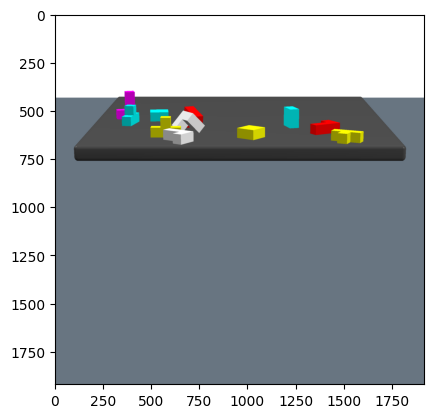

In [158]:
plt.imshow(np.load("./image_dim_0.npy")[1])

In [88]:
def config_to_point_cloud(C: ry.Config, camera_frame: str):
    cam = ry.CameraView(C)

    cam.setCamera(C.getFrame(camera_frame))

    rgb, depth = cam.computeImageAndDepth(C)

    fxycxy = cam.getFxycxy()

    points = ry.depthImage2PointCloud(depth, fxycxy)

    h, w, _ = rgb.shape
    colors = rgb.reshape((h * w, 3))

    mask = points[:, 2] > 5
    points = points * mask
    colors = colors * mask

    return points, colors

C.addFrame("world").setPosition(box_center)
cam = C.addFrame(name="cam_dim_0", parent="world", args='Q:"t(0 0 5) d(180 1 0 0)", shape:camera, width:500, height:500')

points, colors = config_to_point_cloud(C, "cam_dim_0")
print("Point cloud size:", points.shape)

-- WARNING:kin.cpp:addFrame:145(-1) frame 'world' already exists! returning existing without modifications!
-- WARNING:kin.cpp:addFrame:145(-1) frame 'cam_dim_0' already exists! returning existing without modifications!


ValueError: operands could not be broadcast together with shapes (250000,3) (500,3) 

In [72]:
C.view()

0

IndexError: boolean index did not match indexed array along axis 1; size of axis is 500 but size of corresponding boolean axis is 3

In [86]:
points #.shape #[points != [-1.05106413, -1.05106413,  5.07498693]].shape

array([[[-1.05106413, -1.05106413,  5.07498693],
        [-1.04685998, -1.05106413,  5.07498693],
        [-1.04265571, -1.05106413,  5.07498693],
        ...,
        [ 1.03845143, -1.05106413,  5.07498693],
        [ 1.04265571, -1.05106413,  5.07498693],
        [ 1.04685998, -1.05106413,  5.07498693]],

       [[-1.05106413, -1.04685998,  5.07498693],
        [-1.04685998, -1.04685998,  5.07498693],
        [-1.04265571, -1.04685998,  5.07498693],
        ...,
        [ 1.03845143, -1.04685998,  5.07498693],
        [ 1.04265571, -1.04685998,  5.07498693],
        [ 1.04685998, -1.04685998,  5.07498693]],

       [[-1.05106413, -1.04265571,  5.07498693],
        [-1.04685998, -1.04265571,  5.07498693],
        [-1.04265571, -1.04265571,  5.07498693],
        ...,
        [ 1.03845143, -1.04265571,  5.07498693],
        [ 1.04265571, -1.04265571,  5.07498693],
        [ 1.04685998, -1.04265571,  5.07498693]],

       ...,

       [[-1.05106413,  1.03845143,  5.07498693],
        [-1

In [105]:
pts = np.concatenate(points, axis=0)
pts = pts[pts[:, 2] < 5.07]

In [106]:
pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(pts)
pcd = pcd.voxel_down_sample(.00001)
pcd, _ = pcd.remove_statistical_outlier(nb_neighbors=20, std_ratio=10.0)
o3d.visualization.draw_plotly([pcd])

In [144]:
def multi_camera_pointcloud(C: ry.Config, camera_frames: list):
    all_points = []
    all_colors = []

    for cam_name in camera_frames:
        cam = ry.CameraView(C)
        cam_frame = C.getFrame(cam_name)
        cam.setCamera(cam_frame)

        rgb, depth = cam.computeImageAndDepth(C)
        fxycxy = cam.getFxycxy()

        # points in camera frame
        pts_cam = ry.depthImage2PointCloud(depth, fxycxy)

        # reshape colors
        h, w, _ = rgb.shape
        colors = rgb.reshape((-1, 3))

        # 🔑 transform to world frame
        T = cam_frame.getRelativeTransform()  # 4x4 transformation matrix
        print(T.shape)
        R = T[:3, :3]
        t = T[:3, 3]

        pts_cam = np.concatenate(points, axis=0)
        print(pts_cam.shape)

        pts_world = (R @ pts_cam.T).T + t

        # optional: remove invalid points
        valid = pts_cam[:, 2] < 5
        pts_world = pts_world[valid]

        all_points.append(pts_world)

    # merge all cameras
    all_points = np.vstack(all_points)

    return all_points

In [146]:
C.view()

37

In [145]:
C.addFrame(name="cam_dim_0", parent="world", args='Q:"t(0 0 5) d(180 1 0 0)", shape:camera, size=[1], width:1920, height:1920')
C.addFrame(name="cam_dim_1", parent="world", args='Q:"t(0 5 1.5) d(180 1 0 0) d(-75 1 0 0) d(180 0 0 1)", shape:camera, size=[1], width:1920, height:1920')
C.addFrame(name="cam_dim_2", parent="world", args='Q:"t(0 -5 1.5) d(165 1 0 0) d(90 1 0 0)", shape:camera, width:1920, height:1920')
C.addFrame(name="cam_dim_3", parent="world", args='Q:"t(5 0 1.5) d(180 1 0 0) d(-90 1 0 0) d(195 0 0 1) d(90 0 1 0)", shape:camera, width:1920, height:1920')
C.addFrame(name="cam_dim_4", parent="world", args='Q:"t(-5 0 1.5) d(180 1 0 0) d(-90 1 0 0) d(165 0 0 1) d(-90 0 1 0)", shape:camera, width:1920, height:1920')


points = multi_camera_pointcloud(
    C,
    ["cam_dim_0", "cam_dim_1", "cam_dim_2", "cam_dim_3", "cam_dim_4"]
)

-- WARNING:kin.cpp:addFrame:145(-1) frame 'cam_dim_0' already exists! returning existing without modifications!
-- WARNING:kin.cpp:addFrame:145(-1) frame 'cam_dim_1' already exists! returning existing without modifications!
-- WARNING:kin.cpp:addFrame:145(-1) frame 'cam_dim_2' already exists! returning existing without modifications!
-- WARNING:kin.cpp:addFrame:145(-1) frame 'cam_dim_3' already exists! returning existing without modifications!
-- WARNING:kin.cpp:addFrame:145(-1) frame 'cam_dim_4' already exists! returning existing without modifications!
(4, 4)
(2160,)


ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 2160 is different from 3)

In [ ]:
points

(720, 3)

In [139]:
pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(points)
pcd = pcd.voxel_down_sample(.00001)
pcd, _ = pcd.remove_statistical_outlier(nb_neighbors=20, std_ratio=10.0)
o3d.visualization.draw_plotly([pcd])